# Gerçek Klasik CNN Modeli — Adil Karşılaştırma Sürümü

Bu notebook, ANN/MLP ile aynı olmayan gerçek bir CNN sınıflandırıcı başlığı kullanır.  
Önce **EfficientNet-B0** ile uzamsal özellik haritaları çıkarılır; ardından bu haritalar **Conv2D + BatchNorm + SiLU + Pooling** tabanlı CNN başlığına verilir.

Akış:

```text
MR görüntüleri
→ EfficientNet-B0 feature map çıkarımı
→ kanal bazlı standardizasyon
→ Conv2D tabanlı CNN sınıflandırıcı
→ 5 katlı Stratified K-Fold hiperparametre araması
→ sınıf bazlı doğru / yanlış tahmin tablosu
```

Not: Bu sürümde PCA + MLP kullanılmaz. Böylece ANN modeliyle birebir aynı yapı oluşmaz.


## Veri yolu düzeltmesi

Bu sürümde veri klasörü daha esnek algılanır. Notebook artık şu yapıları otomatik arar:

- `Data/glioma_tumor`, `Data/meningioma_tumor`, ...
- `Data/Training/glioma_tumor` + `Data/Testing/glioma_tumor`
- `glioma`, `meningioma`, `no_tumor/notumor`, `pituitary` gibi alternatif klasör adları
- `MyDrive/Beyin_MR_Kuantum_Makale` altında birkaç seviye derinde bulunan veri klasörleri

Yine hata alınırsa, ayarlar hücresindeki `DATA_ROOT` satırını veri setinin ana klasörüne manuel olarak yazmak yeterlidir.


In [1]:
# ============================================================
# GERÇEK KLASİK CNN MODELİ - ADİL KARŞILAŞTIRMA SÜRÜMÜ
# ============================================================
# Bu model ANN/MLP ile aynı değildir.
# EfficientNet-B0'dan PCA vektörü değil, uzamsal feature map çıkarır.
# Ardından Conv2D tabanlı CNN sınıflandırıcı başlığı kullanır.
# ============================================================

# Colab Drive bağlama
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive bağlanamadı veya Colab dışında çalışıyorsunuz:", e)

# Kurulumlar
!pip -q install --upgrade pip
!pip -q install torchvision scikit-learn pandas tqdm matplotlib joblib openpyxl

# Importlar
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision.transforms as T
import torchvision.models as models

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 1) GENEL AYARLAR
# ============================================================
SEED = 42


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", DEVICE)

# Veri klasörü
DATA_ROOT = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data"

CLASS_NAMES = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}
N_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
TEST_SIZE = 0.20
N_FOLDS = 5

# Feature map çıkarımı için batch boyutu
FEATURE_BATCH_SIZE = 32

# Eğitim ayarları
SEARCH_MAX_EPOCHS = 40
SEARCH_PATIENCE = 7
FINAL_MIN_EPOCHS = 8

# Feature mapleri yeniden çıkarmak istersen True yap
FORCE_REEXTRACT_FEATURE_MAPS = False

# Cache klasörleri
CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_true_cnn_fair"
os.makedirs(CACHE_DIR, exist_ok=True)

# Önceki adil karşılaştırma modellerindeki split varsa aynı train/test ayrımını kullanır.
REFERENCE_CNN_MLP_CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp"
REFERENCE_TRAIN_SPLIT_PATH = os.path.join(REFERENCE_CNN_MLP_CACHE_DIR, "train_split.csv")
REFERENCE_TEST_SPLIT_PATH = os.path.join(REFERENCE_CNN_MLP_CACHE_DIR, "test_split.csv")

LOCAL_TRAIN_SPLIT_PATH = os.path.join(CACHE_DIR, "train_split.csv")
LOCAL_TEST_SPLIT_PATH = os.path.join(CACHE_DIR, "test_split.csv")

TRAIN_SPLIT_PATH = REFERENCE_TRAIN_SPLIT_PATH if os.path.exists(REFERENCE_TRAIN_SPLIT_PATH) else LOCAL_TRAIN_SPLIT_PATH
TEST_SPLIT_PATH = REFERENCE_TEST_SPLIT_PATH if os.path.exists(REFERENCE_TEST_SPLIT_PATH) else LOCAL_TEST_SPLIT_PATH

FEATURE_MAP_CACHE_PATH = os.path.join(CACHE_DIR, f"efficientnet_b0_feature_maps_seed{SEED}_img{IMG_SIZE}.npz")
NORMALIZER_SAVE_PATH = os.path.join(CACHE_DIR, "feature_map_channel_normalizer.joblib")
MODEL_SAVE_PATH = os.path.join(CACHE_DIR, "true_classical_cnn_model.pt")
SEARCH_RESULTS_PATH = os.path.join(CACHE_DIR, "true_cnn_hyperparametre_arama_sonuclari.csv")
DETAIL_TEST_RESULTS_PATH = os.path.join(CACHE_DIR, "test_goruntu_bazli_sonuclar.csv")
CLASS_SUMMARY_PATH = os.path.join(CACHE_DIR, "sinif_bazli_dogru_yanlis_sonuclar.csv")
CONFUSION_DETAIL_PATH = os.path.join(CACHE_DIR, "siniflar_arasi_karisiklik_tablosu.csv")
EXCEL_RESULTS_PATH = os.path.join(CACHE_DIR, "CNN_sonuclari.xlsx")

print("Sınıf eşlemesi:", CLASS_TO_IDX)
print("Train split yolu:", TRAIN_SPLIT_PATH)
print("Test split yolu :", TEST_SPLIT_PATH)
print("Cache klasörü   :", CACHE_DIR)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.2 MB/s eta 0:00:00
Kullanılan cihaz: cpu
Sınıf eşlemesi: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Train split yolu: /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp/train_split.csv
Test split yolu : /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp/test_split.csv
Cache klasörü   : /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_true_cnn_fair


In [2]:
# ============================================================
# 2) VERİLERİ LİSTELEME VE TRAIN/TEST BÖLME
# ============================================================
# Desteklenen veri yapıları:
# 1) Data/glioma_tumor, Data/meningioma_tumor, ...
# 2) Data/Training/glioma_tumor + Data/Testing/glioma_tumor, ...
# 3) glioma, meningioma, no_tumor/notumor, pituitary gibi alternatif klasör adları
# 4) Veri klasörü MyDrive içinde farklı bir alt klasördeyse otomatik tarama
# ============================================================

IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")

CLASS_ALIASES = {
    "glioma_tumor": ["glioma_tumor", "glioma", "glioma tumor", "Glioma", "Glioma Tumor"],
    "meningioma_tumor": ["meningioma_tumor", "meningioma", "meningioma tumor", "Meningioma", "Meningioma Tumor"],
    "no_tumor": ["no_tumor", "notumor", "no tumor", "normal", "No Tumor", "No_Tumor"],
    "pituitary_tumor": ["pituitary_tumor", "pituitary", "pituitary tumor", "Pituitary", "Pituitary Tumor"],
}

TRAIN_ALIASES = ["Training", "Train", "train", "training", "TRAIN"]
TEST_ALIASES = ["Testing", "Test", "test", "testing", "TEST"]


def normalize_folder_name(name):
    """Klasör adlarını karşılaştırmak için sadeleştirir."""
    return str(name).lower().replace(" ", "").replace("_", "").replace("-", "")


def find_child_dir(parent, aliases):
    """parent içinde verilen aliaslardan birine karşılık gelen klasörü döndürür."""
    if not os.path.isdir(parent):
        return None

    try:
        children = [d for d in os.listdir(parent) if os.path.isdir(os.path.join(parent, d))]
    except Exception:
        return None

    normalized_children = {normalize_folder_name(d): os.path.join(parent, d) for d in children}
    for alias in aliases:
        key = normalize_folder_name(alias)
        if key in normalized_children:
            return normalized_children[key]
    return None


def list_images(folder):
    files = []
    if not os.path.isdir(folder):
        return files
    for root, _, names in os.walk(folder):
        for name in names:
            if name.lower().endswith(IMAGE_EXTS):
                files.append(os.path.join(root, name))
    return sorted(files)


def get_class_dirs_flat(root, class_names):
    class_dirs = {}
    for cls in class_names:
        folder = find_child_dir(root, CLASS_ALIASES.get(cls, [cls]))
        if folder is None:
            return None
        class_dirs[cls] = folder
    return class_dirs


def collect_class_files_at_root(root, class_names, verbose=True):
    """Belirli bir root altında sınıf dosyalarını toplar. Bulamazsa None döndürür."""
    if not os.path.isdir(root):
        return None

    # 1) Düz yapı: root/sınıf_adi
    flat_dirs = get_class_dirs_flat(root, class_names)
    if flat_dirs is not None:
        flat_files = {cls: list_images(flat_dirs[cls]) for cls in class_names}
        if all(len(flat_files[cls]) > 0 for cls in class_names):
            if verbose:
                print("\nVeri düzeni algılandı: düz sınıf klasörleri")
                print("Algılanan ana klasör:", root)
                for cls in class_names:
                    print(f"  {cls}: {flat_dirs[cls]} -> {len(flat_files[cls])} görüntü")
            return flat_files, "flat", root

    # 2) Training + Testing yapısı
    train_root = find_child_dir(root, TRAIN_ALIASES)
    test_root = find_child_dir(root, TEST_ALIASES)
    if train_root is not None and test_root is not None:
        train_dirs = get_class_dirs_flat(train_root, class_names)
        test_dirs = get_class_dirs_flat(test_root, class_names)
        if train_dirs is not None or test_dirs is not None:
            split_files = {}
            for cls in class_names:
                files_train = list_images(train_dirs[cls]) if train_dirs is not None and cls in train_dirs else []
                files_test = list_images(test_dirs[cls]) if test_dirs is not None and cls in test_dirs else []
                split_files[cls] = sorted(list(dict.fromkeys(files_train + files_test)))

            if all(len(split_files[cls]) > 0 for cls in class_names):
                if verbose:
                    print("\nVeri düzeni algılandı: Training + Testing")
                    print("Algılanan ana klasör:", root)
                    print("Training klasörü:", train_root)
                    print("Testing klasörü :", test_root)
                    print("Not: Training ve Testing birleştirildi; sonra sınıf bazlı 80/20 split yapılacak.")
                    for cls in class_names:
                        print(f"  {cls}: {len(split_files[cls])} görüntü")
                return split_files, "training_testing_combined", root

    return None


def looks_like_dataset_root(root, class_names):
    """Hızlı kontrol: görüntüleri saymadan klasör yapısı uygun mu?"""
    if not os.path.isdir(root):
        return False

    flat_dirs = get_class_dirs_flat(root, class_names)
    if flat_dirs is not None:
        return True

    train_root = find_child_dir(root, TRAIN_ALIASES)
    test_root = find_child_dir(root, TEST_ALIASES)
    if train_root is None and test_root is None:
        return False

    ok_train = get_class_dirs_flat(train_root, class_names) is not None if train_root else False
    ok_test = get_class_dirs_flat(test_root, class_names) is not None if test_root else False
    return ok_train or ok_test


def candidate_roots_from_defaults(data_root):
    candidates = []

    def add(p):
        if p and p not in candidates:
            candidates.append(p)

    add(data_root)
    add(os.path.dirname(data_root))
    add(os.path.join(os.path.dirname(data_root), "Data"))
    add(os.path.join(os.path.dirname(data_root), "Dataset"))
    add(os.path.join(os.path.dirname(data_root), "dataset"))
    add(os.path.join(os.path.dirname(data_root), "archive"))

    add("/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data")
    add("/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Dataset")
    add("/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/dataset")
    add("/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/archive")
    add("/content/drive/MyDrive/Beyin_MR_Kuantum_Makale")

    add("/content/drive/MyDrive/Data")
    add("/content/drive/MyDrive/Dataset")
    add("/content/drive/MyDrive/dataset")
    add("/content/drive/MyDrive/Brain_Tumor_MRI_Dataset")
    add("/content/drive/MyDrive/brain_tumor_dataset")
    add("/content/drive/MyDrive")

    add("/content/Data")
    add("/content/dataset")
    add("/content")
    return candidates


def scan_for_dataset_root(base_dirs, class_names, max_depth=5):
    """Drive içinde sınıf klasörlerini arar. Cache klasörlerini atlar."""
    skip_tokens = [
        "cache", ".git", "__pycache__", "checkpoint", "checkpoints",
        "model", "models", "runs", "wandb"
    ]

    checked = 0
    for base in base_dirs:
        if not os.path.isdir(base):
            continue

        print(f"\nOtomatik veri klasörü taranıyor: {base}")
        for root, dirnames, _ in os.walk(base):
            rel = os.path.relpath(root, base)
            depth = 0 if rel == "." else rel.count(os.sep) + 1

            # Gereksiz/çok büyük klasörleri tarama dışında bırak.
            dirnames[:] = [
                d for d in dirnames
                if not any(tok in d.lower() for tok in skip_tokens)
            ]

            if depth > max_depth:
                dirnames[:] = []
                continue

            checked += 1
            if looks_like_dataset_root(root, class_names):
                found = collect_class_files_at_root(root, class_names, verbose=True)
                if found is not None:
                    print(f"\nOtomatik taramada veri klasörü bulundu. Kontrol edilen klasör sayısı: {checked}")
                    return found

    return None


def collect_class_files(data_root, class_names):
    """Veri klasörünü önce verilen yolda, sonra olası Drive klasörlerinde otomatik arar."""
    # Önce hızlı adayları kontrol et.
    for root in candidate_roots_from_defaults(data_root):
        found = collect_class_files_at_root(root, class_names, verbose=True)
        if found is not None:
            return found

    # Sonra daha genel ama sınırlı tarama yap.
    scan_bases = [
        "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale",
        "/content/drive/MyDrive",
        "/content"
    ]
    found = scan_for_dataset_root(scan_bases, class_names, max_depth=5)
    if found is not None:
        return found

    print("\nVeri klasörü bulunamadı veya sınıf klasörleri boş görünüyor.")
    print("İlk kontrol edilen DATA_ROOT:", data_root)
    if os.path.isdir(data_root):
        try:
            print("DATA_ROOT içeriği:", sorted(os.listdir(data_root))[:50])
        except Exception:
            pass
    else:
        print("DATA_ROOT mevcut değil:", data_root)

    print("\nLütfen ayarlar hücresindeki DATA_ROOT satırını veri setinin ana klasörüne göre düzenleyin.")
    print("Örnek 1: DATA_ROOT = '/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data'")
    print("Örnek 2: DATA_ROOT = '/content/drive/MyDrive/.../Brain_Tumor_MRI_Dataset'")
    print("Beklenen alt klasörler: glioma_tumor, meningioma_tumor, no_tumor, pituitary_tumor")
    print("veya Training/Testing altında bu sınıf klasörleri.")

    raise FileNotFoundError("Sınıf görüntüleri bulunamadı. DATA_ROOT yolunu kontrol edin.")


def build_classwise_split_from_files(class_files, class_names, test_size=0.2, seed=42):
    train_items = []
    test_items = []
    class_counts = {}

    for cls in class_names:
        files = sorted(class_files[cls])
        class_counts[cls] = len(files)
        if len(files) == 0:
            raise ValueError(f"Bu sınıf için görüntü bulunamadı: {cls}")

        y = CLASS_TO_IDX[cls]
        tr, te = train_test_split(files, test_size=test_size, random_state=seed, shuffle=True)
        train_items.extend([(p, y, cls) for p in tr])
        test_items.extend([(p, y, cls) for p in te])

    rng = np.random.default_rng(seed)
    rng.shuffle(train_items)
    rng.shuffle(test_items)
    return train_items, test_items, class_counts


def save_split_csv(items, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    pd.DataFrame(items, columns=["path", "label", "class_name"]).to_csv(path, index=False)


def load_split_csv(path):
    df = pd.read_csv(path)
    return [(str(r["path"]), int(r["label"]), str(r["class_name"])) for _, r in df.iterrows()]


def split_paths_are_valid(items):
    return len(items) > 0 and all(os.path.exists(p) for p, _, _ in items)


use_saved_split = os.path.exists(TRAIN_SPLIT_PATH) and os.path.exists(TEST_SPLIT_PATH)

if use_saved_split:
    print("\nKayıtlı train/test ayrımı kontrol ediliyor.")
    train_items = load_split_csv(TRAIN_SPLIT_PATH)
    test_items = load_split_csv(TEST_SPLIT_PATH)

    if split_paths_are_valid(train_items) and split_paths_are_valid(test_items):
        print("Kayıtlı train/test ayrımı yüklendi ve dosya yolları geçerli.")
        class_counts = {
            cls: sum(1 for _, _, class_name in train_items + test_items if class_name == cls)
            for cls in CLASS_NAMES
        }
    else:
        print("Kayıtlı split var ancak dosya yolları geçersiz. Split yeniden oluşturulacak.")
        use_saved_split = False

if not use_saved_split:
    class_files, detected_layout, detected_root = collect_class_files(DATA_ROOT, CLASS_NAMES)
    DATA_ROOT = detected_root
    print("\nAktif DATA_ROOT:", DATA_ROOT)

    train_items, test_items, class_counts = build_classwise_split_from_files(
        class_files, CLASS_NAMES, test_size=TEST_SIZE, seed=SEED
    )
    save_split_csv(train_items, TRAIN_SPLIT_PATH)
    save_split_csv(test_items, TEST_SPLIT_PATH)

print("\nSınıf bazlı toplam görüntü sayısı:")
display(pd.DataFrame([{"Sınıf": cls, "Görüntü sayısı": class_counts[cls]} for cls in CLASS_NAMES]))
print(f"\nEğitim görüntü sayısı: {len(train_items)}")
print(f"Test görüntü sayısı   : {len(test_items)}")



Kayıtlı train/test ayrımı kontrol ediliyor.
Kayıtlı train/test ayrımı yüklendi ve dosya yolları geçerli.

Sınıf bazlı toplam görüntü sayısı:


,Sınıf,Görüntü sayısı
0,glioma_tumor,926
1,meningioma_tumor,937
2,no_tumor,500
3,pituitary_tumor,901



Eğitim görüntü sayısı: 2609
Test görüntü sayısı   : 655


In [3]:
# ============================================================
# 3) EFFICIENTNET-B0 FEATURE MAP ÇIKARIMI
# ============================================================
# Burada PCA vektörü çıkarılmıyor.
# EfficientNet-B0'ın son 1x1 conv katmanından önceki 7x7 uzamsal feature mapleri çıkarılır.
# Çıktı yaklaşık: [N, 320, 7, 7]
# Bu yapı CNN başlığı için uzamsal bilgiyi korur.
# ============================================================

class MRImageDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label, class_name = self.items[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, int(label), path, class_name


transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def get_efficientnet_b0_feature_extractor():
    weights = models.EfficientNet_B0_Weights.DEFAULT
    effnet = models.efficientnet_b0(weights=weights)

    # Son Conv2dNormActivation bloğu çıkarılır.
    # Böylece 1280 yerine 320 kanallı 7x7 feature map alınır.
    # Bu hem daha hafif hem de CNN başlığı için yeterli uzamsal bilgi taşır.
    feature_extractor = nn.Sequential(*list(effnet.features.children())[:-1])
    feature_extractor.eval()
    for p in feature_extractor.parameters():
        p.requires_grad = False
    return feature_extractor.to(DEVICE)


@torch.no_grad()
def extract_feature_maps(items, batch_size=32):
    dataset = MRImageDataset(items, transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

    feature_extractor = get_efficientnet_b0_feature_extractor()

    all_features = []
    all_labels = []
    all_paths = []
    all_class_names = []

    for images, labels, paths, class_names in tqdm(loader, desc="EfficientNet-B0 feature map çıkarımı"):
        images = images.to(DEVICE)
        feats = feature_extractor(images)
        all_features.append(feats.cpu().numpy().astype(np.float16))
        all_labels.append(labels.numpy())
        all_paths.extend(list(paths))
        all_class_names.extend(list(class_names))

    X = np.concatenate(all_features, axis=0)
    y = np.concatenate(all_labels, axis=0).astype(np.int64)
    return X, y, np.array(all_paths), np.array(all_class_names)


def cache_is_valid(cache_data, train_items, test_items):
    try:
        cached_train_paths = [str(x) for x in cache_data["train_paths"]]
        cached_test_paths = [str(x) for x in cache_data["test_paths"]]
        current_train_paths = [p for p, _, _ in train_items]
        current_test_paths = [p for p, _, _ in test_items]
        return cached_train_paths == current_train_paths and cached_test_paths == current_test_paths
    except Exception:
        return False


if os.path.exists(FEATURE_MAP_CACHE_PATH) and not FORCE_REEXTRACT_FEATURE_MAPS:
    print("\nKayıtlı EfficientNet-B0 feature map cache kontrol ediliyor.")
    cache = np.load(FEATURE_MAP_CACHE_PATH, allow_pickle=True)
    if cache_is_valid(cache, train_items, test_items):
        print("Feature map cache geçerli; yükleniyor.")
        X_train_maps = cache["X_train_maps"]
        y_train = cache["y_train"].astype(np.int64)
        train_paths = cache["train_paths"]
        train_class_names = cache["train_class_names"]
        X_test_maps = cache["X_test_maps"]
        y_test = cache["y_test"].astype(np.int64)
        test_paths = cache["test_paths"]
        test_class_names = cache["test_class_names"]
    else:
        print("Feature map cache mevcut ama split ile uyumlu değil; yeniden çıkarılacak.")
        FORCE_REEXTRACT_FEATURE_MAPS = True

if (not os.path.exists(FEATURE_MAP_CACHE_PATH)) or FORCE_REEXTRACT_FEATURE_MAPS:
    print("\nTrain feature mapleri çıkarılıyor...")
    X_train_maps, y_train, train_paths, train_class_names = extract_feature_maps(train_items, FEATURE_BATCH_SIZE)

    print("\nTest feature mapleri çıkarılıyor...")
    X_test_maps, y_test, test_paths, test_class_names = extract_feature_maps(test_items, FEATURE_BATCH_SIZE)

    np.savez_compressed(
        FEATURE_MAP_CACHE_PATH,
        X_train_maps=X_train_maps,
        y_train=y_train,
        train_paths=train_paths,
        train_class_names=train_class_names,
        X_test_maps=X_test_maps,
        y_test=y_test,
        test_paths=test_paths,
        test_class_names=test_class_names,
    )
    print("Feature map cache kaydedildi:", FEATURE_MAP_CACHE_PATH)

print("\nTrain feature map şekli:", X_train_maps.shape)
print("Test feature map şekli :", X_test_maps.shape)
print("Train sınıf dağılımı:", np.bincount(y_train, minlength=N_CLASSES))
print("Test sınıf dağılımı :", np.bincount(y_test, minlength=N_CLASSES))

# Kanal bazlı standardizasyon: her kanal için train setinden mean/std hesaplanır.
# Uzamsal 7x7 yapı bozulmaz.
def standardize_feature_maps(X_train, X_test):
    X_train_f = X_train.astype(np.float32)
    X_test_f = X_test.astype(np.float32)
    mean = X_train_f.mean(axis=(0, 2, 3), keepdims=True)
    std = X_train_f.std(axis=(0, 2, 3), keepdims=True) + 1e-6
    X_train_n = (X_train_f - mean) / std
    X_test_n = (X_test_f - mean) / std
    return X_train_n.astype(np.float32), X_test_n.astype(np.float32), mean.astype(np.float32), std.astype(np.float32)


X_train_maps, X_test_maps, fmap_mean, fmap_std = standardize_feature_maps(X_train_maps, X_test_maps)
joblib.dump({"mean": fmap_mean, "std": fmap_std}, NORMALIZER_SAVE_PATH)
print("Feature map kanal standardizasyonu tamamlandı.")



Kayıtlı EfficientNet-B0 feature map cache kontrol ediliyor.
Feature map cache geçerli; yükleniyor.

Train feature map şekli: (2609, 320, 7, 7)
Test feature map şekli : (655, 320, 7, 7)
Train sınıf dağılımı: [740 749 400 720]
Test sınıf dağılımı : [186 188 100 181]
Feature map kanal standardizasyonu tamamlandı.


In [4]:
# ============================================================
# 4) GERÇEK CNN SINIFLANDIRICI BAŞLIĞI VE EĞİTİM FONKSİYONLARI
# ============================================================

class TrueCNNHead(nn.Module):
    """EfficientNet feature mapleri üzerinde çalışan gerçek Conv2D tabanlı sınıflandırıcı."""

    def __init__(self, in_channels, n_classes, head_channels=128, dropout=0.35):
        super().__init__()
        mid_channels = max(32, head_channels // 2)

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, head_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(head_channels),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(head_channels, head_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(head_channels),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(head_channels, mid_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.SiLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(mid_channels, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def make_loader(X, y, batch_size=64, shuffle=True):
    dataset = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)


def get_class_weights(y):
    classes = np.arange(N_CLASSES)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


@torch.no_grad()
def predict_model(model, X, batch_size=128):
    model.eval()
    loader = make_loader(X, np.zeros(len(X), dtype=np.int64), batch_size=batch_size, shuffle=False)
    logits_all = []
    probs_all = []

    for xb, _ in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        logits_all.append(logits.cpu().numpy())
        probs_all.append(probs.cpu().numpy())

    logits_all = np.concatenate(logits_all, axis=0)
    probs_all = np.concatenate(probs_all, axis=0)
    preds = probs_all.argmax(axis=1)
    return preds, probs_all, logits_all


def train_with_early_stopping(X_tr, y_tr, X_val, y_val, config, max_epochs=40, patience=7):
    seed_everything(SEED)

    in_channels = X_tr.shape[1]
    model = TrueCNNHead(
        in_channels=in_channels,
        n_classes=N_CLASSES,
        head_channels=config["head_channels"],
        dropout=config["dropout"]
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=get_class_weights(y_tr),
        label_smoothing=config.get("label_smoothing", 0.0)
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    train_loader = make_loader(X_tr, y_tr, batch_size=config["batch_size"], shuffle=True)

    best_state = None
    best_macro_f1 = -1.0
    best_epoch = 0
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            losses.append(float(loss.item()))

        val_pred, val_prob, _ = predict_model(model, X_val, batch_size=config["batch_size"])
        val_acc = accuracy_score(y_val, val_pred)
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")
        scheduler.step(val_macro_f1)

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "val_acc": val_acc,
            "val_macro_f1": val_macro_f1,
        })

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    return {
        "model": model,
        "best_macro_f1": best_macro_f1,
        "best_epoch": best_epoch,
        "history": pd.DataFrame(history)
    }


def train_final_model(X_train, y_train, config, epochs):
    seed_everything(SEED)

    in_channels = X_train.shape[1]
    model = TrueCNNHead(
        in_channels=in_channels,
        n_classes=N_CLASSES,
        head_channels=config["head_channels"],
        dropout=config["dropout"]
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=get_class_weights(y_train),
        label_smoothing=config.get("label_smoothing", 0.0)
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    train_loader = make_loader(X_train, y_train, batch_size=config["batch_size"], shuffle=True)

    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            losses.append(float(loss.item()))

        history.append({"epoch": epoch, "train_loss": float(np.mean(losses))})
        print(f"Final eğitim epoch {epoch:02d}/{epochs} - loss: {np.mean(losses):.4f}")

    return model, pd.DataFrame(history)


# Hiperparametre arama uzayı
# ANN/LSTM/Transformer modellerindeki 5 konfigürasyon mantığıyla uyumlu olacak şekilde
# CNN için de 5 farklı hiperparametre kombinasyonu denenir.
SEARCH_SPACE = [
    {"head_channels": 64,  "dropout": 0.30, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 64, "label_smoothing": 0.05},
    {"head_channels": 128, "dropout": 0.35, "lr": 7e-4, "weight_decay": 1e-4, "batch_size": 64, "label_smoothing": 0.05},
    {"head_channels": 128, "dropout": 0.40, "lr": 5e-4, "weight_decay": 3e-4, "batch_size": 64, "label_smoothing": 0.07},
    {"head_channels": 192, "dropout": 0.40, "lr": 7e-4, "weight_decay": 3e-4, "batch_size": 32, "label_smoothing": 0.07},
    {"head_channels": 256, "dropout": 0.45, "lr": 5e-4, "weight_decay": 3e-4, "batch_size": 32, "label_smoothing": 0.07},
]

print("CNN başlığı giriş kanal sayısı:", X_train_maps.shape[1])
print("Aranacak hiperparametre kombinasyonu:", len(SEARCH_SPACE))


CNN başlığı giriş kanal sayısı: 320
Aranacak hiperparametre kombinasyonu: 5


In [5]:
# ============================================================
# 5) 5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMASI
# ============================================================

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
search_rows = []

for cfg_idx, config in enumerate(SEARCH_SPACE, start=1):
    print("\n" + "=" * 80)
    print(f"Konfigürasyon {cfg_idx}/{len(SEARCH_SPACE)}: {config}")
    print("=" * 80)

    fold_scores = []
    fold_epochs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_maps, y_train), start=1):
        print(f"\nFold {fold}/{N_FOLDS}")
        X_tr, X_val = X_train_maps[tr_idx], X_train_maps[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        out = train_with_early_stopping(
            X_tr, y_tr,
            X_val, y_val,
            config,
            max_epochs=SEARCH_MAX_EPOCHS,
            patience=SEARCH_PATIENCE
        )

        fold_scores.append(out["best_macro_f1"])
        fold_epochs.append(out["best_epoch"])

        print(
            f"Fold {fold} en iyi Macro-F1: {out['best_macro_f1']:.4f} "
            f"| En iyi epoch: {out['best_epoch']}"
        )

    row = dict(config)
    row.update({
        "mean_cv_macro_f1": float(np.mean(fold_scores)),
        "std_cv_macro_f1": float(np.std(fold_scores)),
        "mean_best_epoch": float(np.mean(fold_epochs)),
        "fold_scores": fold_scores,
        "fold_epochs": fold_epochs,
    })
    search_rows.append(row)

search_df = pd.DataFrame(search_rows)
search_df = search_df.sort_values("mean_cv_macro_f1", ascending=False).reset_index(drop=True)
search_df.to_csv(SEARCH_RESULTS_PATH, index=False)

print("\nHiperparametre arama sonuçları:")
display(search_df)

best_config = {
    "head_channels": int(search_df.loc[0, "head_channels"]),
    "dropout": float(search_df.loc[0, "dropout"]),
    "lr": float(search_df.loc[0, "lr"]),
    "weight_decay": float(search_df.loc[0, "weight_decay"]),
    "batch_size": int(search_df.loc[0, "batch_size"]),
    "label_smoothing": float(search_df.loc[0, "label_smoothing"]),
}
final_epochs = max(FINAL_MIN_EPOCHS, int(round(float(search_df.loc[0, "mean_best_epoch"]))))

print("\nSeçilen en iyi konfigürasyon:", best_config)
print("Final eğitim epoch sayısı:", final_epochs)



Konfigürasyon 1/5: {'head_channels': 64, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'label_smoothing': 0.05}

Fold 1/5
Fold 1 en iyi Macro-F1: 0.9341 | En iyi epoch: 27

Fold 2/5
Fold 2 en iyi Macro-F1: 0.9353 | En iyi epoch: 30

Fold 3/5
Fold 3 en iyi Macro-F1: 0.9311 | En iyi epoch: 17

Fold 4/5
Fold 4 en iyi Macro-F1: 0.9448 | En iyi epoch: 23

Fold 5/5
Fold 5 en iyi Macro-F1: 0.9257 | En iyi epoch: 12

Konfigürasyon 2/5: {'head_channels': 128, 'dropout': 0.35, 'lr': 0.0007, 'weight_decay': 0.0001, 'batch_size': 64, 'label_smoothing': 0.05}

Fold 1/5
Fold 1 en iyi Macro-F1: 0.9356 | En iyi epoch: 22

Fold 2/5
Fold 2 en iyi Macro-F1: 0.9334 | En iyi epoch: 20

Fold 3/5
Fold 3 en iyi Macro-F1: 0.9420 | En iyi epoch: 25

Fold 4/5
Fold 4 en iyi Macro-F1: 0.9419 | En iyi epoch: 30

Fold 5/5
Fold 5 en iyi Macro-F1: 0.9158 | En iyi epoch: 11

Konfigürasyon 3/5: {'head_channels': 128, 'dropout': 0.4, 'lr': 0.0005, 'weight_decay': 0.0003, 'batch_size': 64, 'label

,head_channels,dropout,lr,weight_decay,batch_size,label_smoothing,mean_cv_macro_f1,std_cv_macro_f1,mean_best_epoch,fold_scores,fold_epochs
0,64,0.30,0.0010,0.0001,64,0.05,0.934198,0.006260,21.8,"[0.9341115932682595, 0.9353006168185224, 0.931...","[27, 30, 17, 23, 12]"
1,256,0.45,0.0005,0.0003,32,0.07,0.933920,0.005078,25.0,"[0.928661143447662, 0.9353651467051421, 0.9341...","[19, 36, 26, 24, 20]"
2,128,0.35,0.0007,0.0001,64,0.05,0.933737,0.009582,21.6,"[0.9356492808772534, 0.933411169193992, 0.9419...","[22, 20, 25, 30, 11]"
3,128,0.40,0.0005,0.0003,64,0.07,0.932294,0.005718,23.6,"[0.9366898026479907, 0.9331851731159365, 0.926...","[21, 29, 14, 25, 29]"
4,192,0.40,0.0007,0.0003,32,0.07,0.931225,0.003506,22.0,"[0.9272298161577743, 0.9340167655513946, 0.929...","[23, 21, 23, 17, 26]"



Seçilen en iyi konfigürasyon: {'head_channels': 64, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'label_smoothing': 0.05}
Final eğitim epoch sayısı: 22


Final eğitim epoch 01/22 - loss: 0.9093
Final eğitim epoch 02/22 - loss: 0.6500
Final eğitim epoch 03/22 - loss: 0.5489
Final eğitim epoch 04/22 - loss: 0.5071
Final eğitim epoch 05/22 - loss: 0.4565
Final eğitim epoch 06/22 - loss: 0.4315
Final eğitim epoch 07/22 - loss: 0.4239
Final eğitim epoch 08/22 - loss: 0.4039
Final eğitim epoch 09/22 - loss: 0.3975
Final eğitim epoch 10/22 - loss: 0.3878
Final eğitim epoch 11/22 - loss: 0.3755
Final eğitim epoch 12/22 - loss: 0.3590
Final eğitim epoch 13/22 - loss: 0.3558
Final eğitim epoch 14/22 - loss: 0.3512
Final eğitim epoch 15/22 - loss: 0.3312
Final eğitim epoch 16/22 - loss: 0.3434
Final eğitim epoch 17/22 - loss: 0.3215
Final eğitim epoch 18/22 - loss: 0.3228
Final eğitim epoch 19/22 - loss: 0.3211
Final eğitim epoch 20/22 - loss: 0.3099
Final eğitim epoch 21/22 - loss: 0.3053
Final eğitim epoch 22/22 - loss: 0.3031

Model kaydedildi: /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_true_cnn_fair/true_classical_cnn_model

,glioma_tumor,meningioma_tumor,no_tumor,pituitary_tumor
glioma_tumor,171,12,2,1
meningioma_tumor,10,168,1,9
no_tumor,3,2,94,1
pituitary_tumor,0,1,1,179


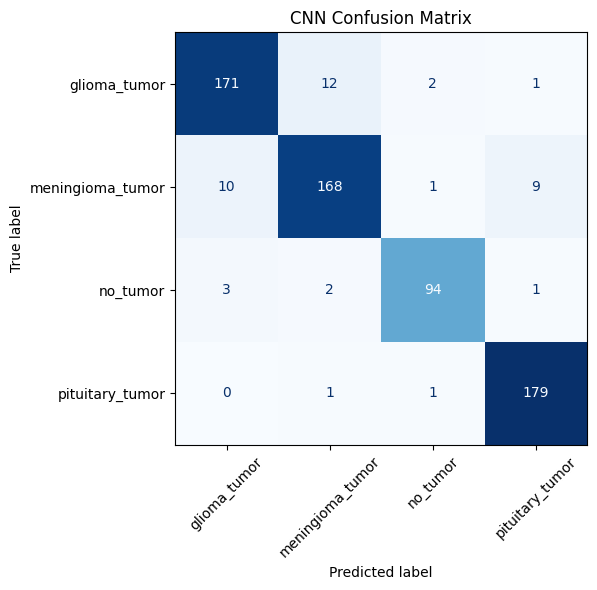


Sınıf bazlı doğru/yanlış tahmin tablosu:


,Model,Sınıf,Test toplam,Doğru tahmin,Yanlış tahmin,Sınıf doğruluğu (%),Yanlış sınıflandırma (%)
0,CNN,glioma_tumor,186,171,15,91.94,8.06
1,CNN,meningioma_tumor,188,168,20,89.36,10.64
2,CNN,no_tumor,100,94,6,94.00,6.00
3,CNN,pituitary_tumor,181,179,2,98.90,1.10
4,CNN,Toplam,655,612,43,93.44,6.56



Makaledeki tabloya uygun geniş format:


,Model,Test toplam,glioma_tumor Doğru tahmin,glioma_tumor Yanlış tahmin,meningioma_tumor Doğru tahmin,meningioma_tumor Yanlış tahmin,no_tumor Doğru tahmin,no_tumor Yanlış tahmin,pituitary_tumor Doğru tahmin,pituitary_tumor Yanlış tahmin,Toplam Doğru tahmin,Toplam Yanlış tahmin
0,CNN,655,171,15,168,20,94,6,179,2,612,43


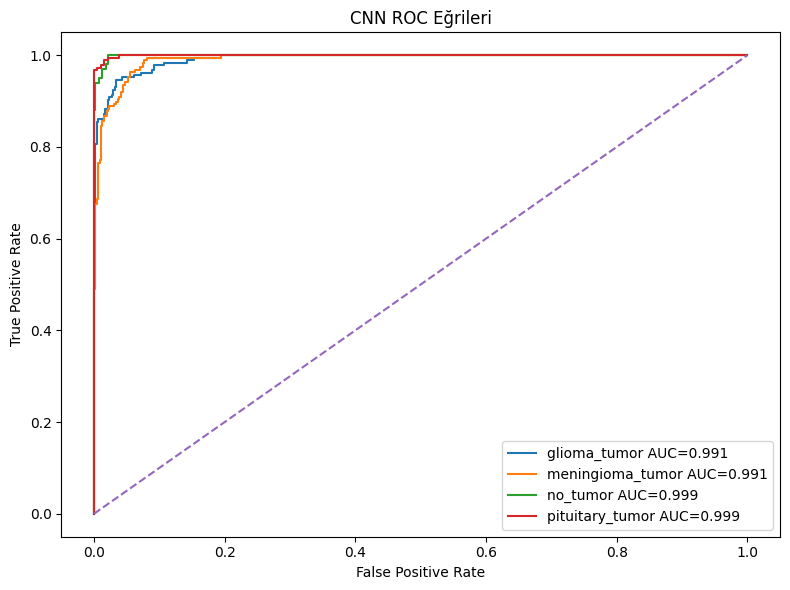


Kaydedilen dosyalar:
Sınıf bazlı tablo: /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_true_cnn_fair/sinif_bazli_dogru_yanlis_sonuclar.csv
Geniş tablo ve diğer sonuçlar: /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_true_cnn_fair/CNN_sonuclari.xlsx
Görüntü bazlı sonuçlar: /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_true_cnn_fair/test_goruntu_bazli_sonuclar.csv


In [6]:
# ============================================================
# 6) FINAL EĞİTİM VE TEST DEĞERLENDİRME
# ============================================================

# ------------------------------------------------------------
# Güvenlik düzeltmesi:
# Bazı çalıştırmalarda train_final_model fonksiyonu bellekte tanımlı
# olmayabiliyor. Final eğitimden hemen önce kontrol edilip eksikse
# burada yeniden tanımlanır.
# ------------------------------------------------------------
if "train_final_model" not in globals():
    print("UYARI: train_final_model bellekte yoktu; yeniden tanımlanıyor.")

    def train_final_model(X_train, y_train, config, epochs):
        seed_everything(SEED)

        in_channels = X_train.shape[1]
        model = TrueCNNHead(
            in_channels=in_channels,
            n_classes=N_CLASSES,
            head_channels=config["head_channels"],
            dropout=config["dropout"]
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(
            weight=get_class_weights(y_train),
            label_smoothing=config.get("label_smoothing", 0.0)
        )
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
        train_loader = make_loader(
            X_train,
            y_train,
            batch_size=config["batch_size"],
            shuffle=True
        )

        history = []
        for epoch in range(1, epochs + 1):
            model.train()
            losses = []
            for xb, yb in train_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                optimizer.zero_grad(set_to_none=True)
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
                losses.append(float(loss.item()))

            mean_loss = float(np.mean(losses)) if len(losses) else np.nan
            history.append({"epoch": epoch, "train_loss": mean_loss})
            print(f"Final eğitim epoch {epoch:02d}/{epochs} - loss: {mean_loss:.4f}")

        return model, pd.DataFrame(history)


final_model, final_history = train_final_model(X_train_maps, y_train, best_config, epochs=final_epochs)
torch.save({
    "model_state_dict": final_model.state_dict(),
    "best_config": best_config,
    "final_epochs": final_epochs,
    "class_names": CLASS_NAMES,
    "feature_map_shape": X_train_maps.shape[1:],
}, MODEL_SAVE_PATH)

print("\nModel kaydedildi:", MODEL_SAVE_PATH)

# Test tahminleri
y_pred, y_proba, y_logits = predict_model(final_model, X_test_maps, batch_size=best_config["batch_size"])

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

try:
    macro_auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
except Exception:
    macro_auc = np.nan

print("\nGenel test sonuçları")
print(f"Accuracy   : {acc:.4f} ({acc*100:.2f}%)")
print(f"Macro-F1   : {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"Weighted-F1: {weighted_f1:.4f} ({weighted_f1*100:.2f}%)")
print(f"Macro-AUC  : {macro_auc:.4f} ({macro_auc*100:.2f}%)")
print(f"Doğru      : {int((y_test == y_pred).sum())}")
print(f"Yanlış     : {int((y_test != y_pred).sum())}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(N_CLASSES)))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
cm_df.to_csv(CONFUSION_DETAIL_PATH)

print("\nConfusion matrix:")
display(cm_df)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()

# Sınıf bazlı doğru/yanlış tablo
class_rows = []
for i, cls in enumerate(CLASS_NAMES):
    total = int(np.sum(y_test == i))
    correct = int(np.sum((y_test == i) & (y_pred == i)))
    wrong = total - correct
    class_rows.append({
        "Model": "CNN",
        "Sınıf": cls,
        "Test toplam": total,
        "Doğru tahmin": correct,
        "Yanlış tahmin": wrong,
        "Sınıf doğruluğu (%)": round(correct / total * 100, 2) if total else np.nan,
        "Yanlış sınıflandırma (%)": round(wrong / total * 100, 2) if total else np.nan,
    })

class_summary_df = pd.DataFrame(class_rows)
class_summary_df.loc[len(class_summary_df)] = {
    "Model": "CNN",
    "Sınıf": "Toplam",
    "Test toplam": int(len(y_test)),
    "Doğru tahmin": int(np.sum(y_test == y_pred)),
    "Yanlış tahmin": int(np.sum(y_test != y_pred)),
    "Sınıf doğruluğu (%)": round(acc * 100, 2),
    "Yanlış sınıflandırma (%)": round((1 - acc) * 100, 2),
}

class_summary_df.to_csv(CLASS_SUMMARY_PATH, index=False)
print("\nSınıf bazlı doğru/yanlış tahmin tablosu:")
display(class_summary_df)

# Kullanıcının istediği geniş tablo formatı
wide_row = {"Model": "CNN", "Test toplam": int(len(y_test))}
for i, cls in enumerate(CLASS_NAMES):
    total = int(np.sum(y_test == i))
    correct = int(np.sum((y_test == i) & (y_pred == i)))
    wrong = total - correct
    wide_row[f"{cls} Doğru tahmin"] = correct
    wide_row[f"{cls} Yanlış tahmin"] = wrong
wide_row["Toplam Doğru tahmin"] = int(np.sum(y_test == y_pred))
wide_row["Toplam Yanlış tahmin"] = int(np.sum(y_test != y_pred))
wide_df = pd.DataFrame([wide_row])

print("\nMakaledeki tabloya uygun geniş format:")
display(wide_df)

# Görüntü bazlı detaylı test sonuçları
detail_df = pd.DataFrame({
    "path": test_paths,
    "true_label": y_test,
    "true_class": [IDX_TO_CLASS[int(i)] for i in y_test],
    "pred_label": y_pred,
    "pred_class": [IDX_TO_CLASS[int(i)] for i in y_pred],
    "correct": y_test == y_pred,
})
for i, cls in enumerate(CLASS_NAMES):
    detail_df[f"prob_{cls}"] = y_proba[:, i]

detail_df.to_csv(DETAIL_TEST_RESULTS_PATH, index=False)

# ROC eğrileri
try:
    y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("CNN ROC Eğrileri")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("ROC çizilemedi:", e)

# Excel çıktı
with pd.ExcelWriter(EXCEL_RESULTS_PATH, engine="openpyxl") as writer:
    wide_df.to_excel(writer, sheet_name="Geniş Tablo", index=False)
    class_summary_df.to_excel(writer, sheet_name="Sınıf Bazlı", index=False)
    cm_df.to_excel(writer, sheet_name="Confusion Matrix")
    search_df.to_excel(writer, sheet_name="CV Arama", index=False)
    detail_df.to_excel(writer, sheet_name="Görüntü Bazlı", index=False)

print("\nKaydedilen dosyalar:")
print("Sınıf bazlı tablo:", CLASS_SUMMARY_PATH)
print("Geniş tablo ve diğer sonuçlar:", EXCEL_RESULTS_PATH)
print("Görüntü bazlı sonuçlar:", DETAIL_TEST_RESULTS_PATH)
